# Supporting datasets: cleaning and EDA

Uses the three project periods. Numeric source values are preserved. See outputs/supporting_data_eda/RESULTS.md for interpretation limits.

## Setup and audit

In [1]:
"""Reproducible cleaning, EDA, and charts for the four supporting CSVs."""
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / 'data/raw').is_dir() else Path.cwd().parent
OUT = ROOT / 'outputs' / 'supporting_data_eda'
for folder in [OUT, OUT / 'clean', OUT / 'tables', OUT / 'figures']:
    folder.mkdir(parents=True, exist_ok=True)
PERIODS = ['Smart automobile expansion', 'Transition Year', 'AI expansion']
raw_paths = sorted((ROOT / 'data/raw').glob('*.csv'))
hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in raw_paths}
audit = []
frames = {}

def load(name, keys):
    raw = pd.read_csv(ROOT / 'data/raw' / f'{name}.csv')
    d = raw.copy()
    for c in d.select_dtypes('object'):
        d[c] = d[c].astype('string').str.strip()
    d['year'] = pd.to_numeric(d.year, errors='raise').astype(int)
    assert not d.duplicated(keys).any(), f'Duplicate key in {name}'
    d['analysis_period'] = pd.Series(pd.NA, index=d.index, dtype='string')
    for mask, label in zip([d.year.between(2010, 2021), d.year.eq(2022), d.year.between(2023, 2026)], PERIODS):
        d.loc[mask, 'analysis_period'] = label
    assert d.analysis_period.notna().all()
    d['source_validation_caution'] = d.year.isin([2025, 2026])
    audit.append(dict(dataset=name, rows=len(raw), original_columns=len(raw.columns), missing_original_cells=int(raw.isna().sum().sum()), duplicate_rows=int(raw.duplicated().sum()), duplicate_keys=int(raw.duplicated(keys).sum()), min_year=int(d.year.min()), max_year=int(d.year.max()), record_key=' + '.join(keys)))
    frames[name] = (raw, d)
    return d



## AI-chip cleaning and EDA

In [2]:
ai = load('ai_chip_market', ['year', 'vendor', 'chip_name'])
ai['launch_date_parsed'] = pd.to_datetime(ai.launch_date, format='%d/%m/%Y', errors='raise')
ai['before_launch_year_flag'] = ai.year.lt(ai.launch_date_parsed.dt.year)
ai['zero_asp_flag'] = ai.estimated_asp_usd.eq(0)
ai['zero_memory_flag'] = ai.memory_gb.eq(0)
ai['calculated_revenue_usd_m'] = ai.estimated_shipments_units * ai.estimated_asp_usd / 1e6
ai['revenue_abs_diff_usd_m'] = (ai.estimated_revenue_usd_m - ai.calculated_revenue_usd_m).abs()
ai['revenue_review_flag'] = ai.revenue_abs_diff_usd_m.gt(0.051)
ai['all_market_values_estimated'] = True
ai['performance_per_watt_tflops'] = ai.fp16_tflops / ai.tdp_watts.where(ai.tdp_watts.gt(0))
ai['performance_per_1000_usd'] = ai.fp16_tflops / ai.estimated_asp_usd.where(ai.estimated_asp_usd.gt(0)) * 1000
ai_annual = ai.groupby('year').agg(estimated_shipments_units=('estimated_shipments_units','sum'), estimated_revenue_usd_m=('estimated_revenue_usd_m','sum'), product_count=('chip_name','nunique'), vendor_count=('vendor','nunique'), zero_asp_rows=('zero_asp_flag','sum')).reset_index()
ai_vendor = ai.groupby(['year','vendor'], as_index=False).agg(estimated_revenue_usd_m=('estimated_revenue_usd_m','sum'), estimated_shipments_units=('estimated_shipments_units','sum'))
ai_vendor['revenue_share_within_ai_dataset_pct'] = ai_vendor.estimated_revenue_usd_m / ai_vendor.groupby('year').estimated_revenue_usd_m.transform('sum') * 100



## Monthly price cleaning and EDA

In [3]:
prices = load('chip_prices', ['year_month','product','currency','unit'])
prices['month_date'] = pd.to_datetime(prices.year_month, format='%Y-%m', errors='raise')
prices['year_mismatch_flag'] = prices.year.ne(prices.month_date.dt.year)
assert not prices.year_mismatch_flag.any()
prices.sort_values(['product','currency','unit','month_date'], inplace=True)
pk = ['product','currency','unit']
prices['month_number'] = prices.month_date.dt.year * 12 + prices.month_date.dt.month
prices['previous_month_number'] = prices.groupby(pk).month_number.shift()
prices['previous_price'] = prices.groupby(pk).price.shift()
prices['consecutive_month_flag'] = prices.month_number.sub(prices.previous_month_number).eq(1)
prices['monthly_price_change_pct'] = (prices.price / prices.previous_price.where(prices.previous_price.gt(0)) - 1) * 100
prices.loc[~prices.consecutive_month_flag, 'monthly_price_change_pct'] = np.nan
prices['price_index_first_observed_100'] = prices.price / prices.groupby(pk).price.transform('first').where(lambda s:s.gt(0)) * 100
prices['nonpositive_price_flag'] = prices.price.le(0)
price_annual = prices.groupby(pk + ['year'], as_index=False).agg(mean_price=('price','mean'), minimum_price=('price','min'), maximum_price=('price','max'), months_observed=('month_date','nunique'))
price_annual['full_year_coverage'] = price_annual.months_observed.eq(12)
price_coverage = prices.groupby(pk, as_index=False).agg(first_month=('month_date','min'), last_month=('month_date','max'), observed_months=('month_date','nunique'))
price_coverage['expected_months_within_span'] = (price_coverage.last_month.dt.year-price_coverage.first_month.dt.year)*12 + price_coverage.last_month.dt.month-price_coverage.first_month.dt.month+1
price_coverage['missing_months_within_span'] = price_coverage.expected_months_within_span-price_coverage.observed_months



## Capacity cleaning and EDA

In [4]:
fab = load('fab_capacity', ['year','company','country_iso3','process_node_nm','fab_type'])
fab['capacity_category'] = np.where(fab.fab_type.str.contains('packaging'), 'Packaging', 'Fabrication')
fab['zero_capacity_flag'] = fab.monthly_wafer_capacity.eq(0)
fab['before_start_year_flag'] = fab.year.lt(fab.fab_started_year)
fab['wafer_basis_unverified'] = True
fab_annual = fab.groupby(['year','capacity_category','fab_type'], as_index=False).agg(reported_monthly_wafer_capacity=('monthly_wafer_capacity','sum'), records=('company','size'), companies=('company','nunique'))
fab_company = fab.groupby(['year','company','capacity_category','fab_type'], as_index=False).agg(reported_monthly_wafer_capacity=('monthly_wafer_capacity','sum'))
fab_country = fab.groupby(['year','country_iso3','capacity_category','fab_type'], as_index=False).agg(reported_monthly_wafer_capacity=('monthly_wafer_capacity','sum'))



## Policy-event cleaning and EDA

In [5]:
events = load('export_controls', ['control_id'])
events['date_parsed'] = pd.to_datetime(events.date, format='%d/%m/%Y', errors='raise')
events['date_components_review_flag'] = events.year.ne(events.date_parsed.dt.year) | events.month.ne(events.date_parsed.dt.month)
events['severity_definition_unverified'] = True
events['country_indicator_review_flag'] = False
for country, col in [('USA','is_us_action'),('CHN','is_china_action'),('NLD','is_netherlands_action')]:
    events['country_indicator_review_flag'] |= events[col].ne(events.imposing_country.eq(country).astype(int))
event_annual = events.groupby(['year','imposing_country'], as_index=False).agg(recorded_events=('control_id','size'))
# A zero means no event recorded in this file, not proof that no policy existed.
event_grid = pd.MultiIndex.from_product([range(int(events.year.min()),int(events.year.max())+1),sorted(events.imposing_country.unique())], names=['year','imposing_country'])
event_annual = event_annual.set_index(['year','imposing_country']).reindex(event_grid,fill_value=0).reset_index()



## Financial links and coverage

In [6]:
financials = pd.read_csv(ROOT / 'data/raw/chip_companies_financials.csv')
financial_annual = financials.groupby('year',as_index=False).agg(financial_revenue_usd_bn=('revenue_usd_bn','sum'), financial_company_count=('company_name','nunique'))
annual_context = financial_annual.merge(ai_annual,on='year',how='left',validate='one_to_one').merge(event_annual.groupby('year',as_index=False).recorded_events.sum(),on='year',how='left',validate='one_to_one')
assert len(annual_context) == len(financial_annual)
# Exact entity matches only: no unsupported parent/subsidiary identity mapping.
ai_finance = ai_vendor.merge(financials[['year','company_name','revenue_usd_bn']],left_on=['year','vendor'],right_on=['year','company_name'],how='left',validate='many_to_one',indicator=True)
vendor_mapping = ai_finance.groupby(['vendor','_merge'],observed=True).size().rename('rows').reset_index()

period_coverage = pd.concat([d.groupby('analysis_period',as_index=False).agg(observed_years=('year','nunique'), first_year=('year','min'),last_year=('year','max'),rows=('year','size')).assign(dataset=name) for name,(_,d) in frames.items()],ignore_index=True)
tables = {'audit':pd.DataFrame(audit),'period_coverage':period_coverage,'ai_annual':ai_annual,'ai_vendor_annual':ai_vendor,'price_annual':price_annual,'price_coverage':price_coverage,'fab_annual_by_type':fab_annual,'fab_company_by_type':fab_company,'fab_country_by_type':fab_country,'policy_events_annual':event_annual,'annual_financial_context':annual_context,'ai_financial_exact_matches':ai_finance,'vendor_match_coverage':vendor_mapping}
flags=[]
for name,(raw,d) in frames.items():
    for c in raw.select_dtypes('number'):
        pd.testing.assert_series_equal(raw[c],d.sort_index()[c])
    assert len(raw)==len(d)
    assert not np.isinf(d.select_dtypes('number').to_numpy(dtype=float)).any()
    for c in d.columns:
        if c.endswith('_flag') or c.endswith('_unverified'):
            flags.append({'dataset':name,'flag':c,'rows':int(d[c].sum())})
    path=OUT/'clean'/f'{name}_clean.csv'
    d.to_csv(path,index=False)
    saved=pd.read_csv(path)
    assert saved.shape==d.shape
tables['review_flags']=pd.DataFrame(flags)
for name,table in tables.items():
    table.to_csv(OUT/'tables'/f'{name}.csv',index=False)



## Visualization

In [7]:
plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
chart_files=[]
def finish(fig,name,note):
    fig.text(.02,.015,'Source: supplied CSVs; descriptive analysis. '+note,fontsize=8,wrap=True)
    fig.tight_layout(rect=[0,.075,1,.95])
    path=OUT/'figures'/f'{name}.png'
    fig.savefig(path,dpi=160,bbox_inches='tight')
    chart_files.append(path)
    plt.close(fig)

fig,axes=plt.subplots(2,1,figsize=(11,8),sharex=True)
axes[0].plot(ai_annual.year,ai_annual.estimated_shipments_units/1000,marker='o'); axes[0].set_ylabel('Estimated shipments (thousands)')
axes[1].plot(ai_annual.year,ai_annual.estimated_revenue_usd_m/1000,marker='o',color='#d17c21'); axes[1].set_ylabel('Estimated revenue (USD billions)'); axes[1].set_xlabel('Year')
fig.suptitle('AI-chip estimates and changing product coverage, 2020–2026')
finish(fig,'01_ai_market_trends','Product coverage varies; 2025–2026 require source review. Zero ASP values retained.')

vendor_latest=ai_vendor[ai_vendor.year.eq(2026)].sort_values('estimated_revenue_usd_m')
fig,ax=plt.subplots(figsize=(10,7)); ax.barh(vendor_latest.vendor,vendor_latest.estimated_revenue_usd_m/1000,color='#235b83'); ax.set_xlabel('Estimated revenue (USD billions)'); fig.suptitle('AI-chip dataset revenue by vendor, 2026 — source review required')
finish(fig,'02_ai_vendor_revenue','Estimates for represented products only; not company total revenue or global market share.')

fig,axes=plt.subplots(3,2,figsize=(12,10)); axes=axes.ravel()
for ax,((product,currency,unit),g) in zip(axes,prices.groupby(pk)):
    ax.plot(g.month_date,g.price,color='#235b83'); ax.set_title(product); ax.set_ylabel(unit); ax.tick_params(axis='x',rotation=30)
axes[-1].axis('off'); fig.suptitle('Monthly chip prices in their original units')
finish(fig,'03_monthly_chip_prices','Different units use separate panels. Series end April 2026; annual 2026 averages are partial-year.')

common=prices[prices.month_date.ge('2024-10-01')].copy()
common['index']=common.price/common.groupby(pk).price.transform('first')*100
fig,ax=plt.subplots(figsize=(12,6))
for product,g in common.groupby('product'): ax.plot(g.month_date,g['index'],label=product)
ax.axhline(100,color='gray',lw=.8); ax.set_ylabel('Price index (October 2024 = 100)'); ax.legend(fontsize=8); fig.suptitle('Price changes over the shared observation window')
finish(fig,'04_common_base_price_index','Index compares relative changes, not price levels. October 2024–April 2026; later years require review.')

fig,axes=plt.subplots(3,2,figsize=(12,10))
for ax,(kind,g) in zip(axes.ravel(),fab_annual.groupby('fab_type')):
    ax.plot(g.year,g.reported_monthly_wafer_capacity/1000,marker='o'); ax.set_title(kind); ax.set_ylabel('Reported monthly capacity (thousands)')
    years = sorted(g.year.unique())
    ax.set_xticks(years[::max(1,len(years)//5)])
    if len(years) == 1:
        ax.set_xlim(years[0]-.5,years[0]+.5)
        ax.text(.04,.90,'One observed year only',transform=ax.transAxes,fontsize=8)
fig.suptitle('Reported capacity by factory type — fabrication and packaging kept separate')
finish(fig,'05_capacity_by_type','Sums of listed records within type; wafer size/equivalence and record overlap are unverified. Not actual output.')

fig,ax=plt.subplots(figsize=(12,6))
for i,(country,g) in enumerate(events.groupby('imposing_country')):
    ax.scatter(g.date_parsed,[i]*len(g),s=45,label=country)
ax.set_yticks(range(events.imposing_country.nunique()),sorted(events.imposing_country.unique())); ax.set_xlabel('Recorded event date'); fig.suptitle('Export-control event timeline, 2018–2026')
finish(fig,'06_policy_timeline','Equal-size markers avoid treating undocumented severity scores as calibrated measures; 2025–2026 need review.')

fig,axes=plt.subplots(3,1,figsize=(12,10),sharex=True)
axes[0].plot(annual_context.year,annual_context.financial_revenue_usd_bn,marker='o'); axes[0].set_ylabel('Financial revenue\n(USD billions)')
axes[1].plot(annual_context.year,annual_context.estimated_revenue_usd_m/1000,marker='o',color='#d17c21'); axes[1].set_ylabel('AI-chip estimated revenue\n(USD billions)')
axes[2].bar(annual_context.year,annual_context.recorded_events,color='#67917c'); axes[2].set_ylabel('Recorded policy events'); axes[2].set_xlabel('Year')
for ax in axes:
    ax.axvspan(2010,2021.5,color='#8fa9c1',alpha=.12); ax.axvspan(2021.5,2022.5,color='#e8b25b',alpha=.2); ax.axvspan(2022.5,2026.5,color='#174a7e',alpha=.08); ax.set_xlim(2010,2026.5)
fig.suptitle('Financial outcomes, AI-chip estimates, and policy context\n2010–2021: Smart automobile expansion | 2022: Transition Year | 2023–2026: AI expansion')
finish(fig,'07_financial_ai_policy_context','Different dataset universes; do not add revenue series. Gaps mean unavailable coverage. Co-movement is not causation.')

matched=ai_finance[ai_finance._merge.eq('both') & ai_finance.vendor.isin(['NVIDIA','AMD'])]
fig,axes=plt.subplots(1,2,figsize=(12,6))
for ax,(vendor,g) in zip(axes,matched.groupby('vendor')):
    ax.plot(g.year,g.revenue_usd_bn,marker='o',label='Company financial revenue'); ax.plot(g.year,g.estimated_revenue_usd_m/1000,marker='s',label='AI-chip dataset estimate'); ax.set_title(vendor); ax.set_ylabel('USD billions'); ax.legend(fontsize=8)
fig.suptitle('Exact-name company links: financial revenue and AI-chip estimates')
finish(fig,'08_company_ai_context','Independent series, not a reconciled revenue breakdown; do not subtract to infer non-AI revenue. 2025–2026 need review.')



## Validation and results

In [8]:
assert all(hashlib.sha256(p.read_bytes()).hexdigest()==hashes[p.name] for p in raw_paths)
assert all(p.exists() and p.stat().st_size>0 for p in chart_files)
lines=['# Supporting datasets: cleaning, EDA, and visualization','', 'Completed analysis of all four supporting files. No rows removed, no raw files modified, and original numeric values preserved.','', '## Dataset audit','', '| Dataset | Rows | Years | Missing original cells | Duplicate keys |','|---|---:|---|---:|---:|']
for a in audit: lines.append(f"| {a['dataset']} | {a['rows']} | {a['min_year']}–{a['max_year']} | {a['missing_original_cells']} | {a['duplicate_keys']} |")
lines += ['', '## What was done','', '| Dataset | Cleaning and structure | EDA and charts |', '|---|---|---|', '| AI chips | Explicit day/month/year launch-date parsing; zero-price, zero-memory, pre-launch and revenue-reconciliation flags; safe performance ratios. | Annual shipments/revenue, vendor shares, coverage, and exact-name financial context. Market values are estimates. |', '| Prices | Parse year-month, verify year, order each product series, check monthly gaps, calculate consecutive-month changes and indexes. | Original-unit panels, common October 2024 price index, annual averages with month counts. |', '| Capacity | Verify unique company/country/node/type/year records; separate fabrication from packaging; flag zero capacity and pre-start years. | Annual, company and country summaries within factory type; type-specific trend panels. |', '| Export controls | Parse explicit day/month/year dates; compare date components and country flags; retain undocumented severity scores with a review flag. | Recorded event counts and timeline; aligned financial context without causal claims. |', '', '## Your periods and coverage','', '2010–2021 = Smart automobile expansion; 2022 = Transition Year; 2023–2026 = AI expansion. Coverage is not assumed to span each full period. See tables/period_coverage.csv. Prices run only through April 2026; product launches also produce partial first years. Annual price means are not full-year means unless full_year_coverage is true.', '', '## Review flags','', '| Dataset | Flag | Rows |', '|---|---|---:|']
for f in flags: lines.append(f"| {f['dataset']} | {f['flag']} | {f['rows']} |")
lines += ['', '## Integration and interpretation','', '- Annual financial, AI, and policy tables are joined one-to-one by year. Missing out-of-coverage values remain missing.', '- Vendor/company joins use exact names and many-to-one validation. Unmatched names are documented; no guessed subsidiary mappings.', '- AI estimated revenue and total financial revenue have different scopes and must not be added or interpreted as reconciled components.', '- Monthly wafer capacity is a capacity measure, not actual output. Factory IDs and wafer-equivalence definitions are absent; within-type sums are descriptive sums of supplied records, not verified industry totals. Packaging and fabrication are never pooled.', '- Policy counts represent events listed in this file; zero means none recorded. Severity scores and administration indicators are not externally verified or used as causal exposure measures.', '- Cross-chip performance ratios are nominal descriptors, not comparable benchmark results: architectures, precision conventions, and system boundaries differ. These ratios are not used to rank products in charts.', '- 2025–2026 remain source-review years. All underlying source claims are unverified; this workflow is a data-quality and descriptive analysis, not external factual validation.', '', '## Files','', '- clean/: four cleaned CSVs.', '- tables/: audit, coverage, review flags, annual summaries and validated links.', '- figures/: eight PNG charts.', '- Notebook: notebooks/06_supporting_data_eda.ipynb.', '- Re-run: python src/supporting_data_analysis.py', '', 'Source provenance recorded in docs/data_sources.txt: Kaggle Global Semiconductor Industry 2010–2026. Source contents were not independently verified.']
lines += ['', '## Descriptive findings', '']
for year in [2022,2023,2024]:
    row=ai_annual.loc[ai_annual.year.eq(year)].iloc[0]
    lines.append(f"- {year}: AI-chip dataset estimated revenue was USD {row.estimated_revenue_usd_m/1000:.2f} billion across {int(row.product_count)} products. Changing product coverage contributes to comparability limits.")
for product,g in common.groupby('product'):
    change=g.sort_values('month_date')['index'].iloc[-1]-100
    lines.append(f'- {product}: price changed {change:+.1f}% from October 2024 to April 2026 in the common-window index; 2025–2026 require source review.')
pack_years=sorted(fab.loc[fab.capacity_category.eq('Packaging'),'year'].unique())
lines += [f'- Packaging records cover only {pack_years}; a packaging time trend cannot be inferred from one observed year.' if len(pack_years)==1 else f'- Packaging observed years: {pack_years}.', '- Recorded event counts were 4 in 2022, 7 in 2023, and 6 in 2024. These are dataset event counts, not calibrated policy severity or causal effects.']
(OUT/'RESULTS.md').write_text('\n'.join(lines)+'\n',encoding='utf-8')
(OUT/'validation.json').write_text(json.dumps({'raw_hashes_unchanged':True,'original_numeric_values_preserved':True,'duplicate_keys':0,'no_infinite_clean_values':True,'clean_csv_roundtrip_shapes_valid':True,'charts':len(chart_files),'raw_sha256':hashes},indent=2),encoding='utf-8')
print(pd.DataFrame(audit).to_string(index=False))
print(pd.DataFrame(flags).to_string(index=False))
print('Completed:',OUT)


        dataset  rows  original_columns  missing_original_cells  duplicate_rows  duplicate_keys  min_year  max_year                                                 record_key
 ai_chip_market   120                11                       0               0               0      2020      2026                                  year + vendor + chip_name
    chip_prices   405                 6                       0               0               0      2014      2026                     year_month + product + currency + unit
   fab_capacity   313                 7                       0               0               0      2011      2026 year + company + country_iso3 + process_node_nm + fab_type
export_controls    34                15                       0               0               0      2018      2026                                                 control_id
        dataset                           flag  rows
 ai_chip_market        before_launch_year_flag     0
 ai_chip_market    

period_coverage


,analysis_period,observed_years,first_year,last_year,rows,dataset
0,AI expansion,4,2023,2026,101,ai_chip_market
1,Smart automobile expansion,2,2020,2021,11,ai_chip_market
2,Transition Year,1,2022,2022,8,ai_chip_market
3,AI expansion,4,2023,2026,177,chip_prices
4,Smart automobile expansion,8,2014,2021,192,chip_prices
5,Transition Year,1,2022,2022,36,chip_prices
6,AI expansion,4,2023,2026,152,fab_capacity
7,Smart automobile expansion,11,2011,2021,130,fab_capacity
8,Transition Year,1,2022,2022,31,fab_capacity
9,AI expansion,4,2023,2026,23,export_controls


ai_annual


,year,estimated_shipments_units,estimated_revenue_usd_m,product_count,vendor_count,zero_asp_rows
0,2020,40006,600.1,4,3,0
1,2021,209085,3136.2,7,5,0
2,2022,152204,2283.0,8,6,0
3,2023,991098,23611.1,15,7,1
4,2024,4904042,109819.4,26,11,2
5,2025,4876006,112487.8,30,11,2
6,2026,2935334,70687.7,30,11,2


price_coverage


,product,currency,unit,first_month,last_month,observed_months,expected_months_within_span,missing_months_within_span
0,DRAM_DDR4_8Gb,USD,USD/chip,2014-01-01,2026-04-01,148,148,0
1,HBM3_stack,USD,USD/stack,2022-01-01,2026-04-01,52,52,0
2,NAND_64Gb_MLC,USD,USD/chip,2014-01-01,2026-04-01,148,148,0
3,NVIDIA_B200,USD,USD/unit,2024-10-01,2026-04-01,19,19,0
4,NVIDIA_H100,USD,USD/unit,2023-03-01,2026-04-01,38,38,0


review_flags


,dataset,flag,rows
0,ai_chip_market,before_launch_year_flag,0
1,ai_chip_market,zero_asp_flag,7
2,ai_chip_market,zero_memory_flag,3
3,ai_chip_market,revenue_review_flag,0
4,chip_prices,year_mismatch_flag,0
5,chip_prices,consecutive_month_flag,400
6,chip_prices,nonpositive_price_flag,0
7,fab_capacity,zero_capacity_flag,38
8,fab_capacity,before_start_year_flag,0
9,fab_capacity,wafer_basis_unverified,313


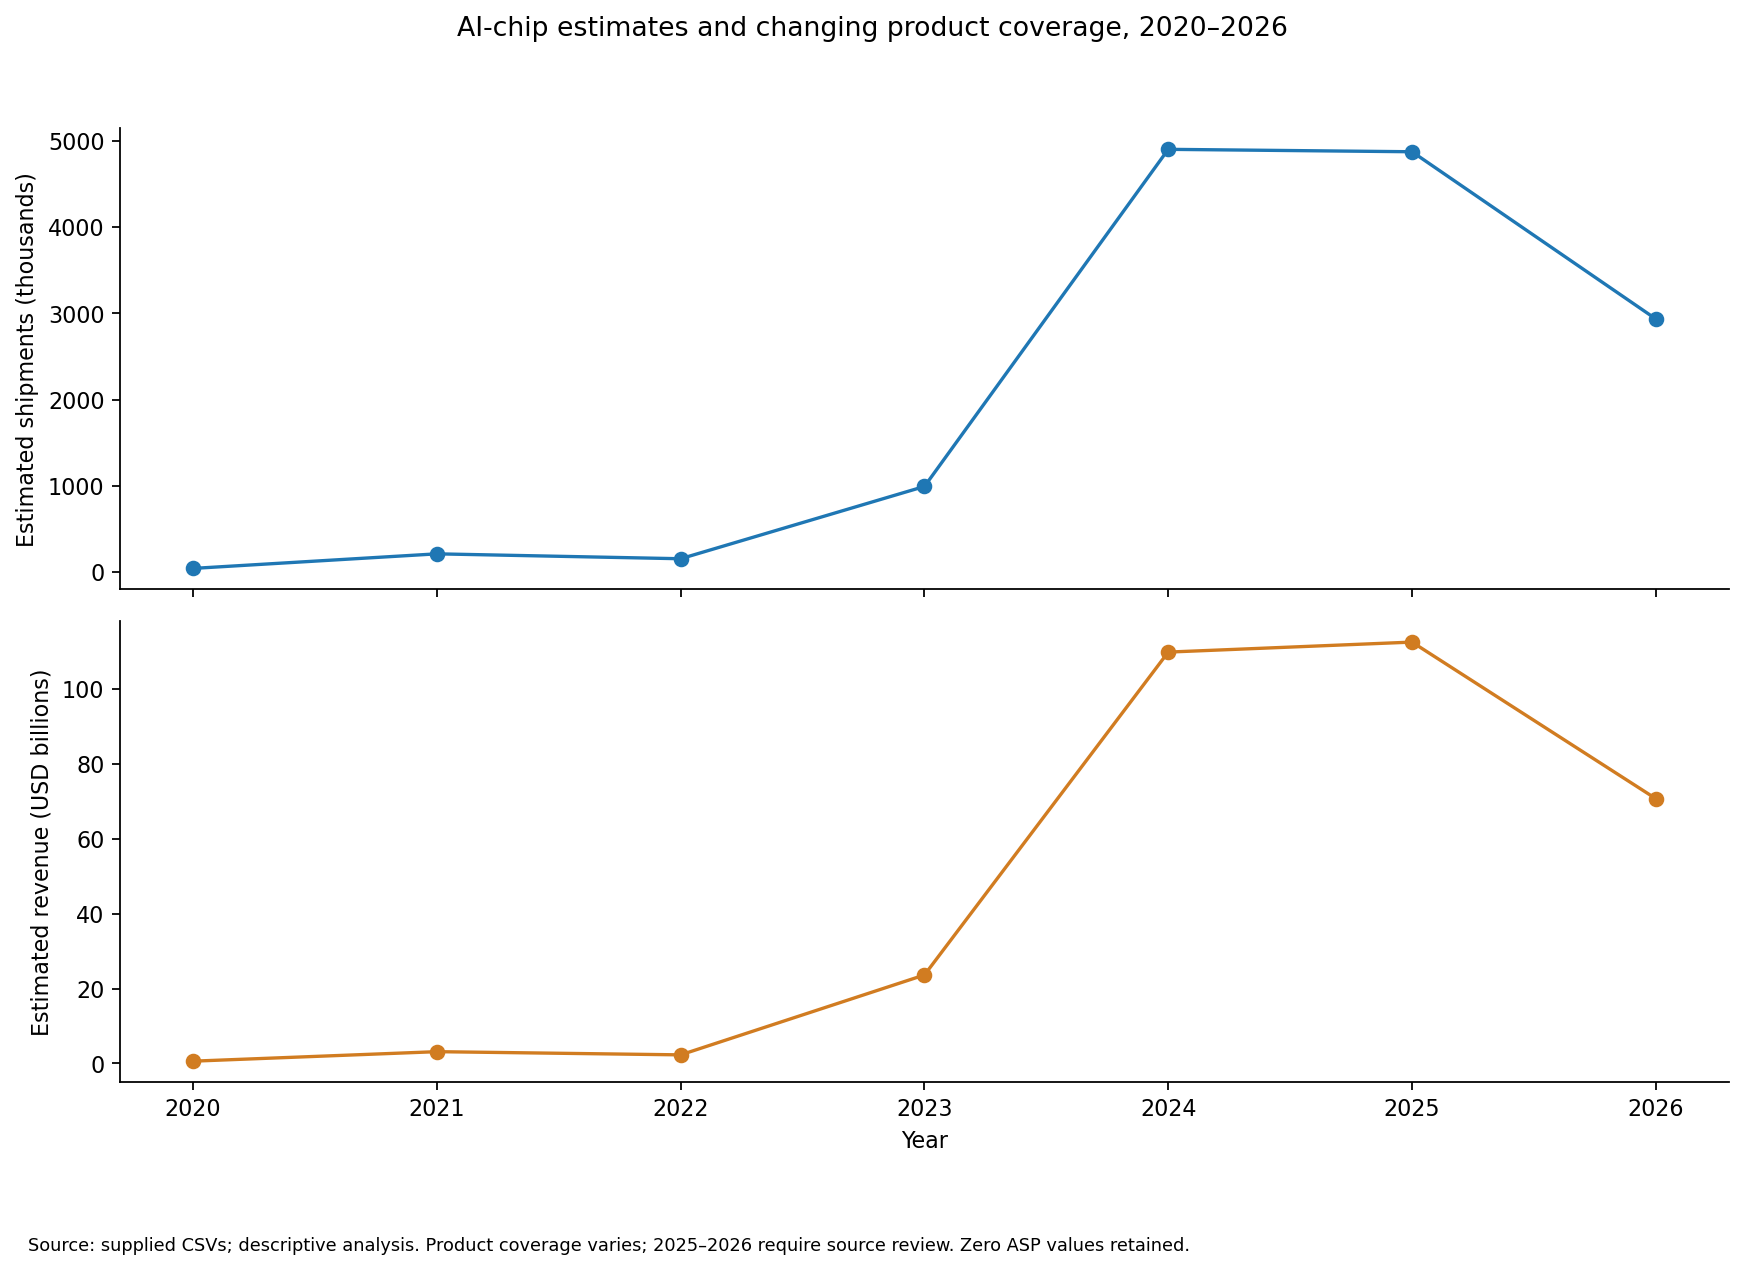

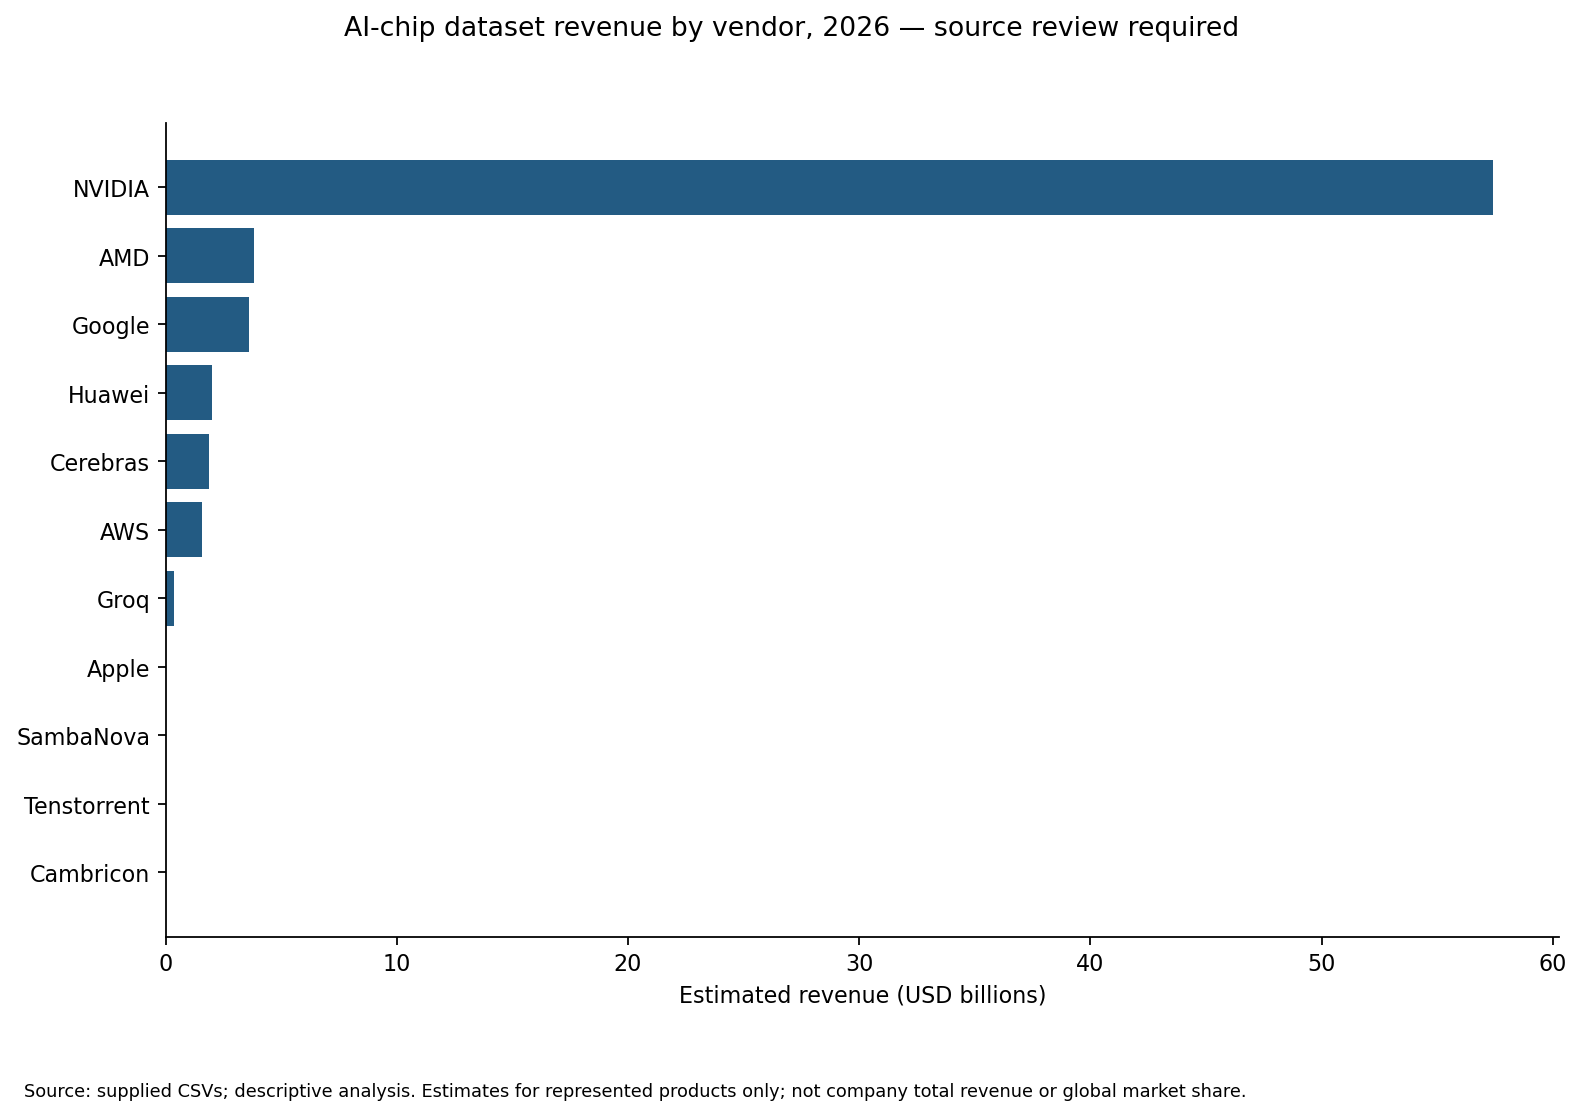

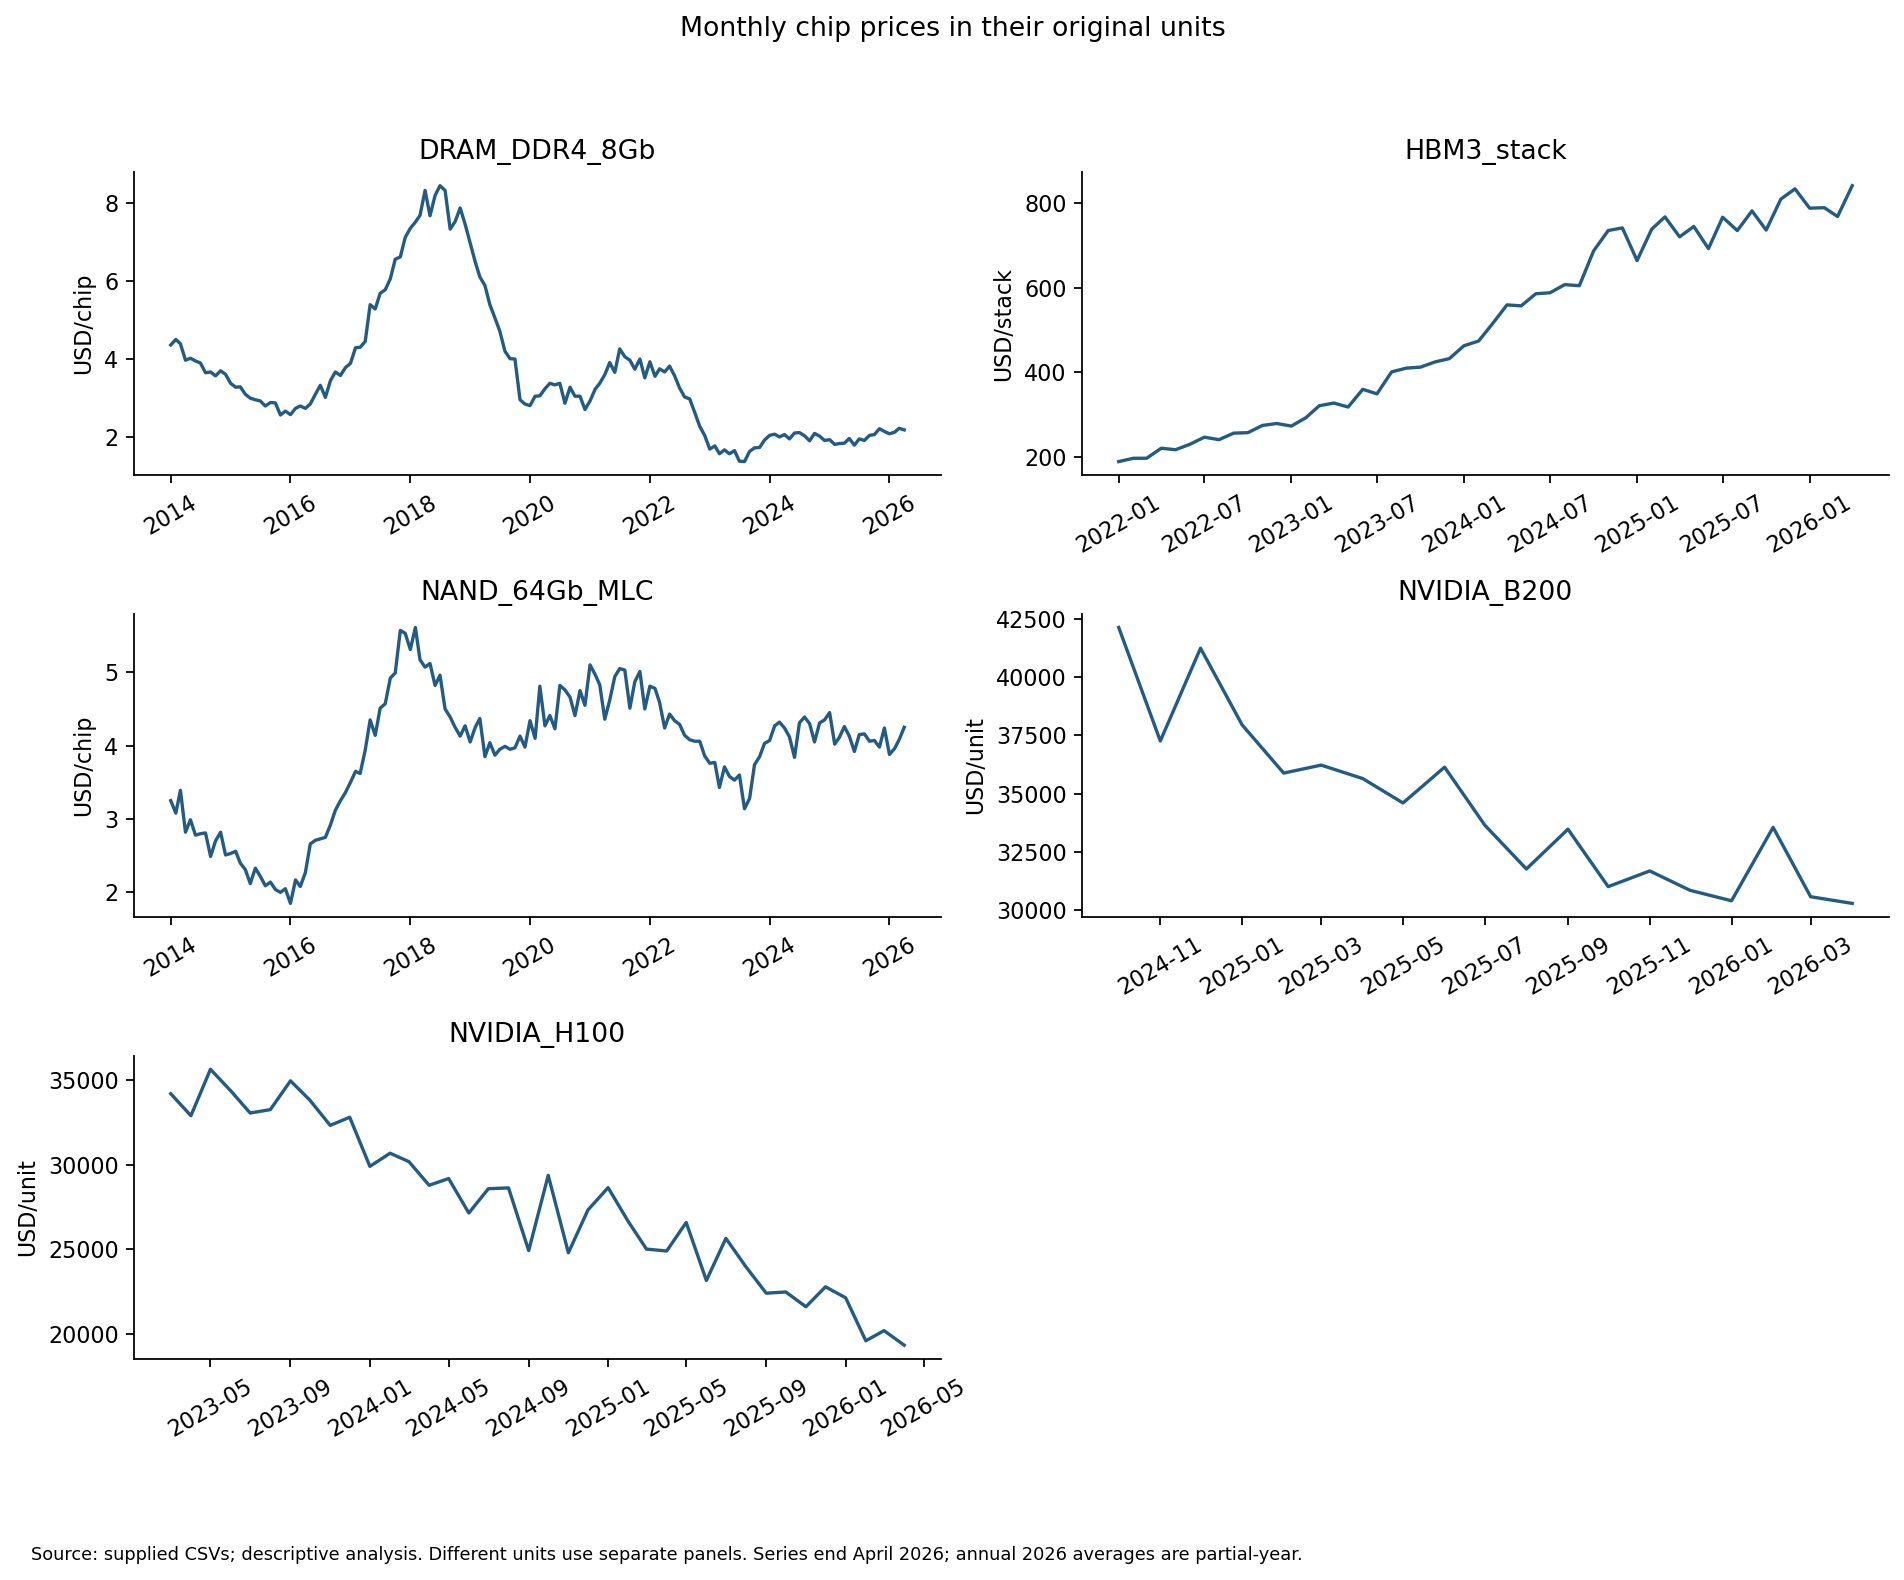

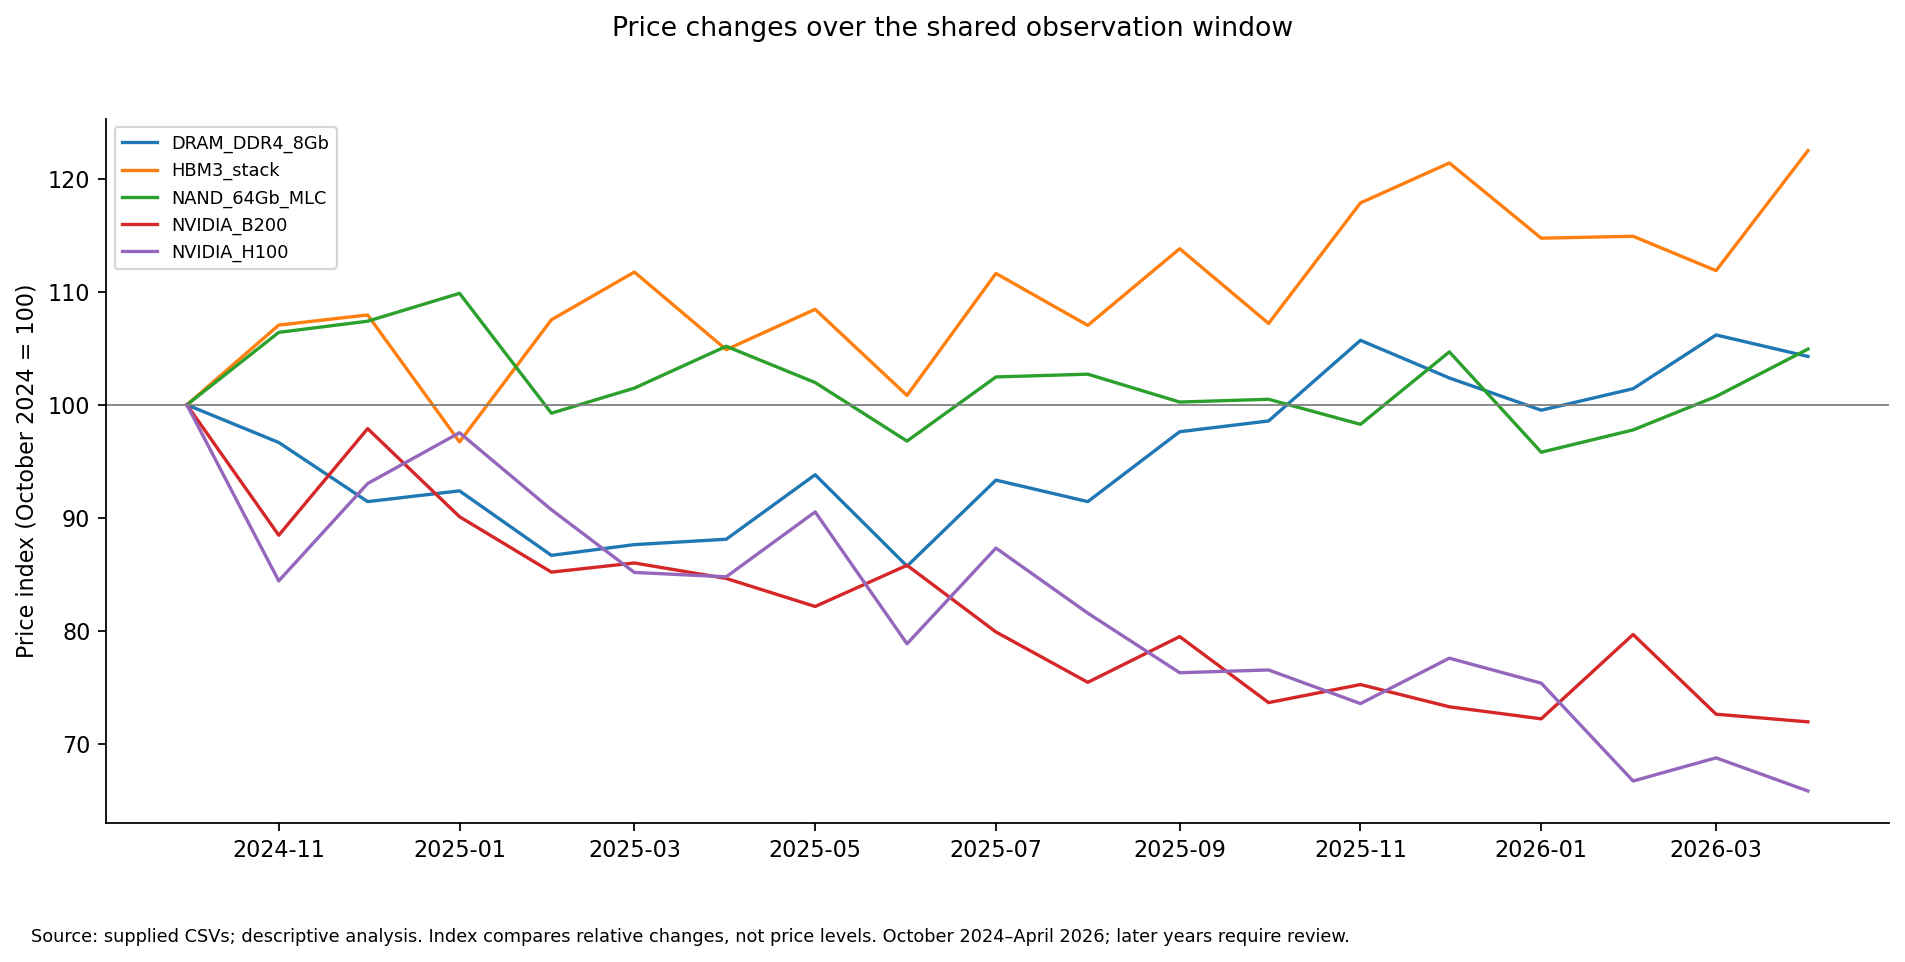

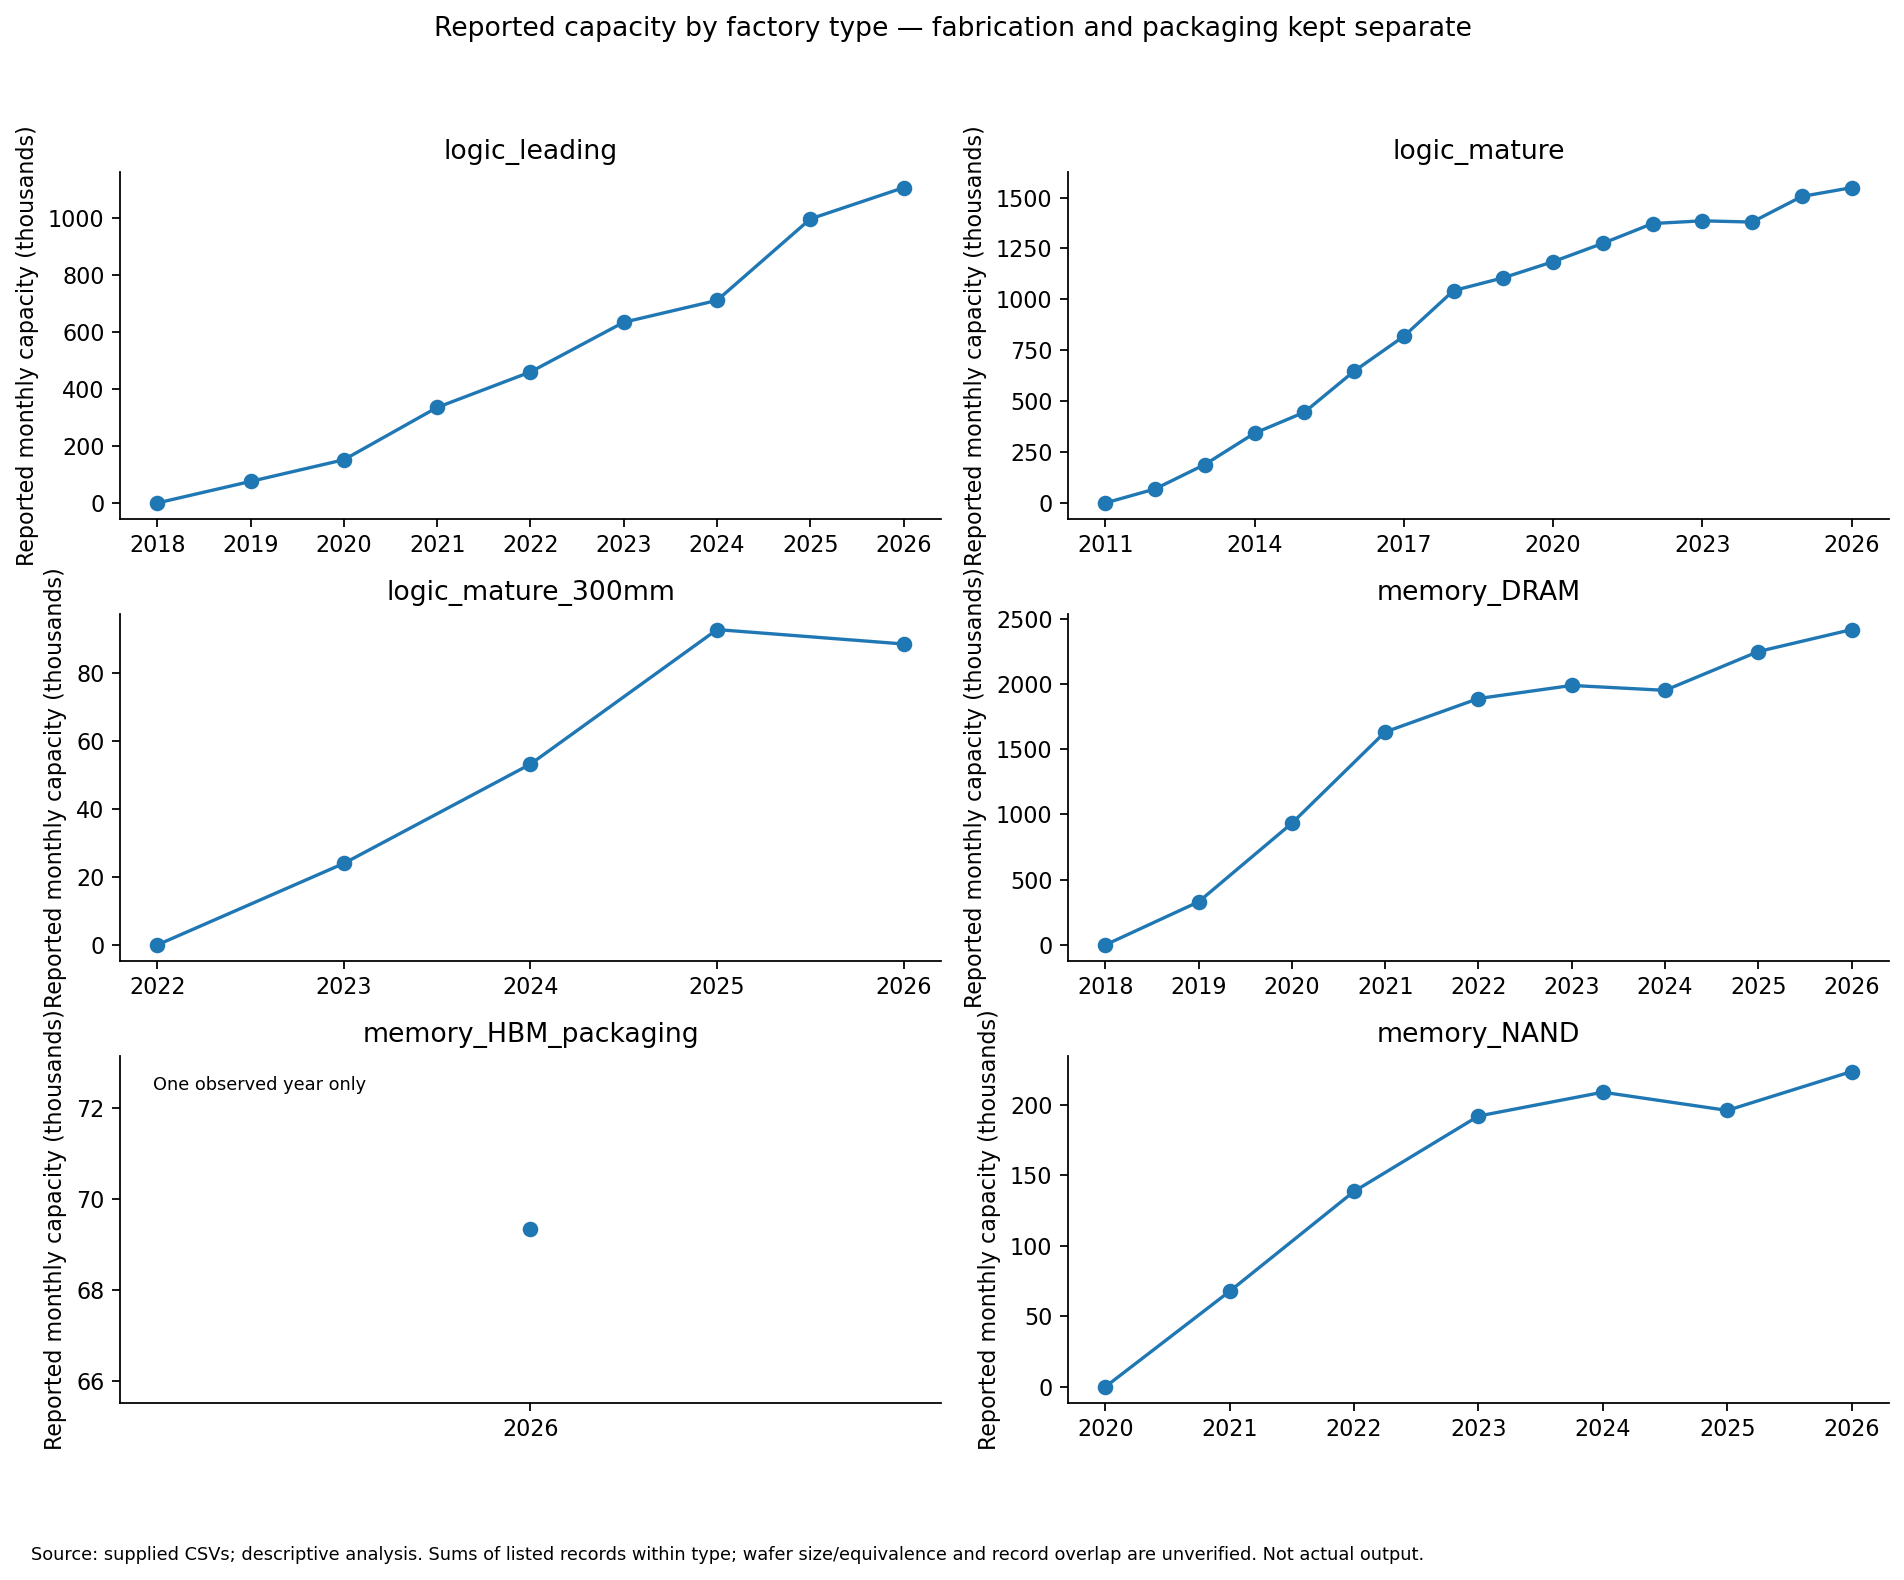

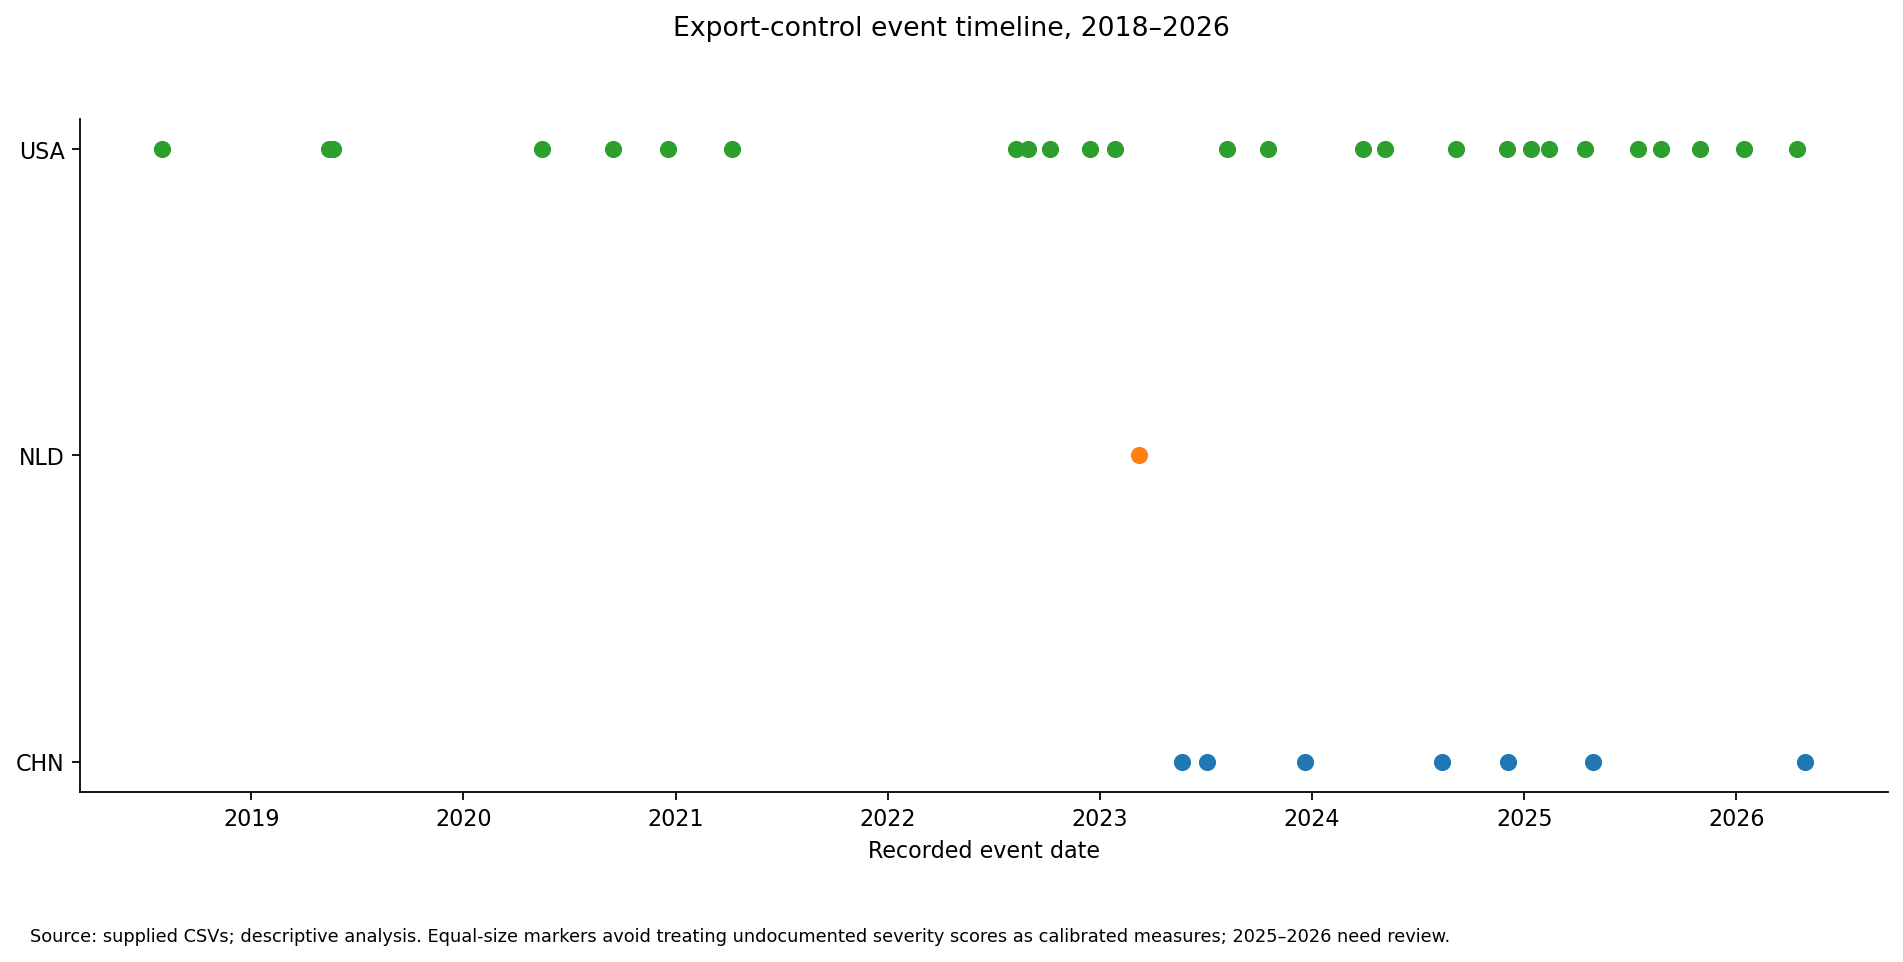

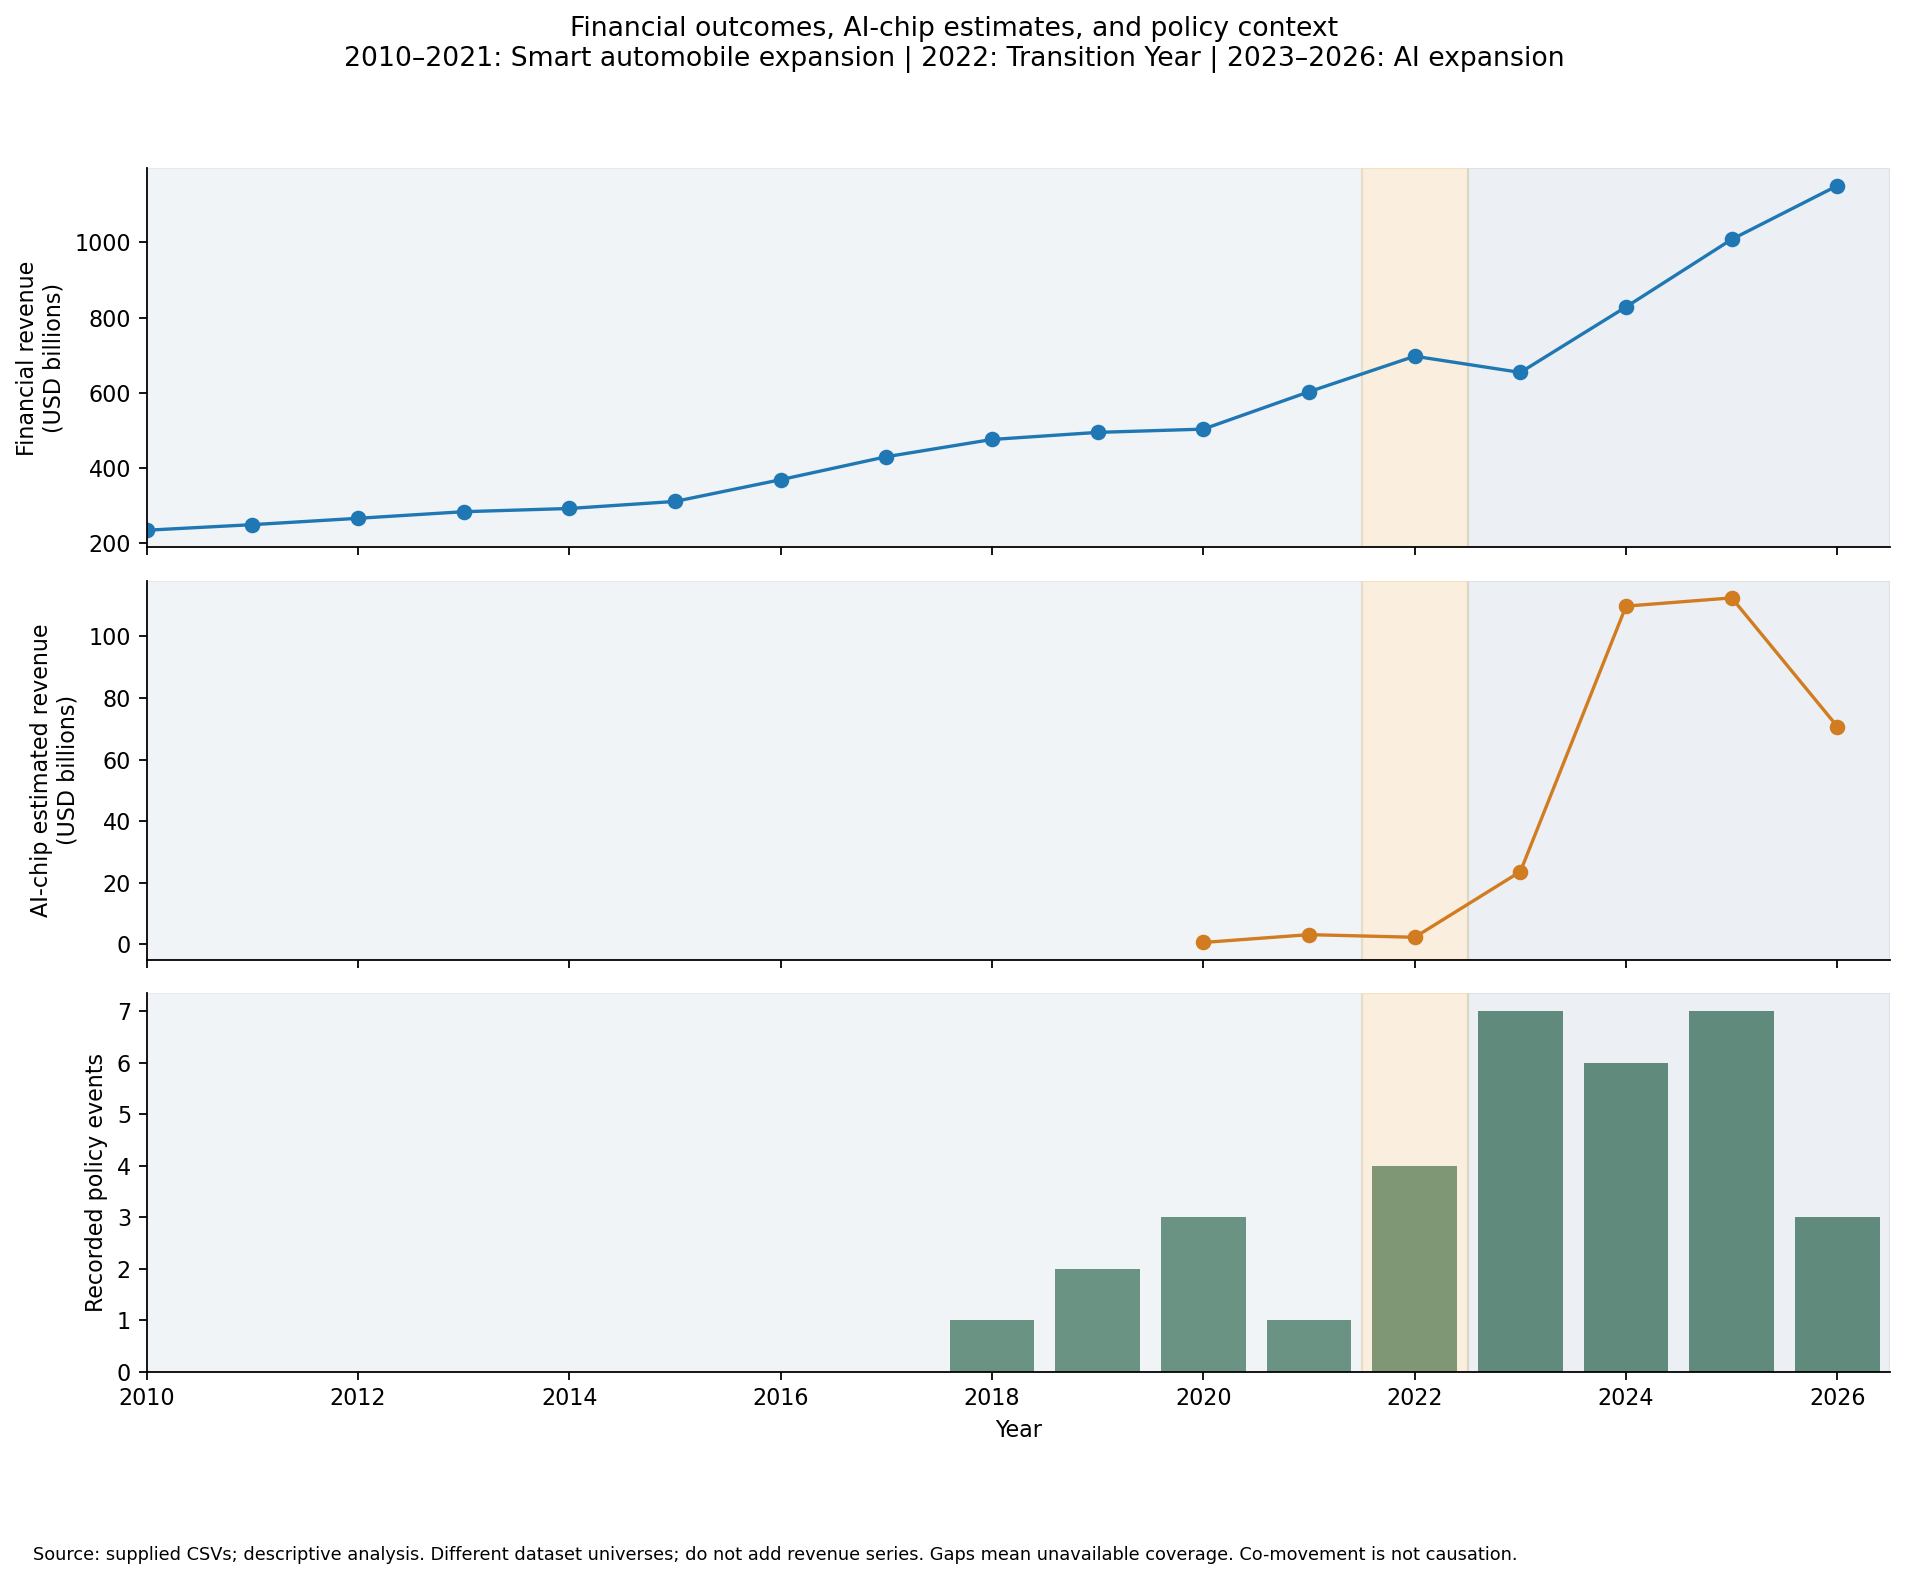

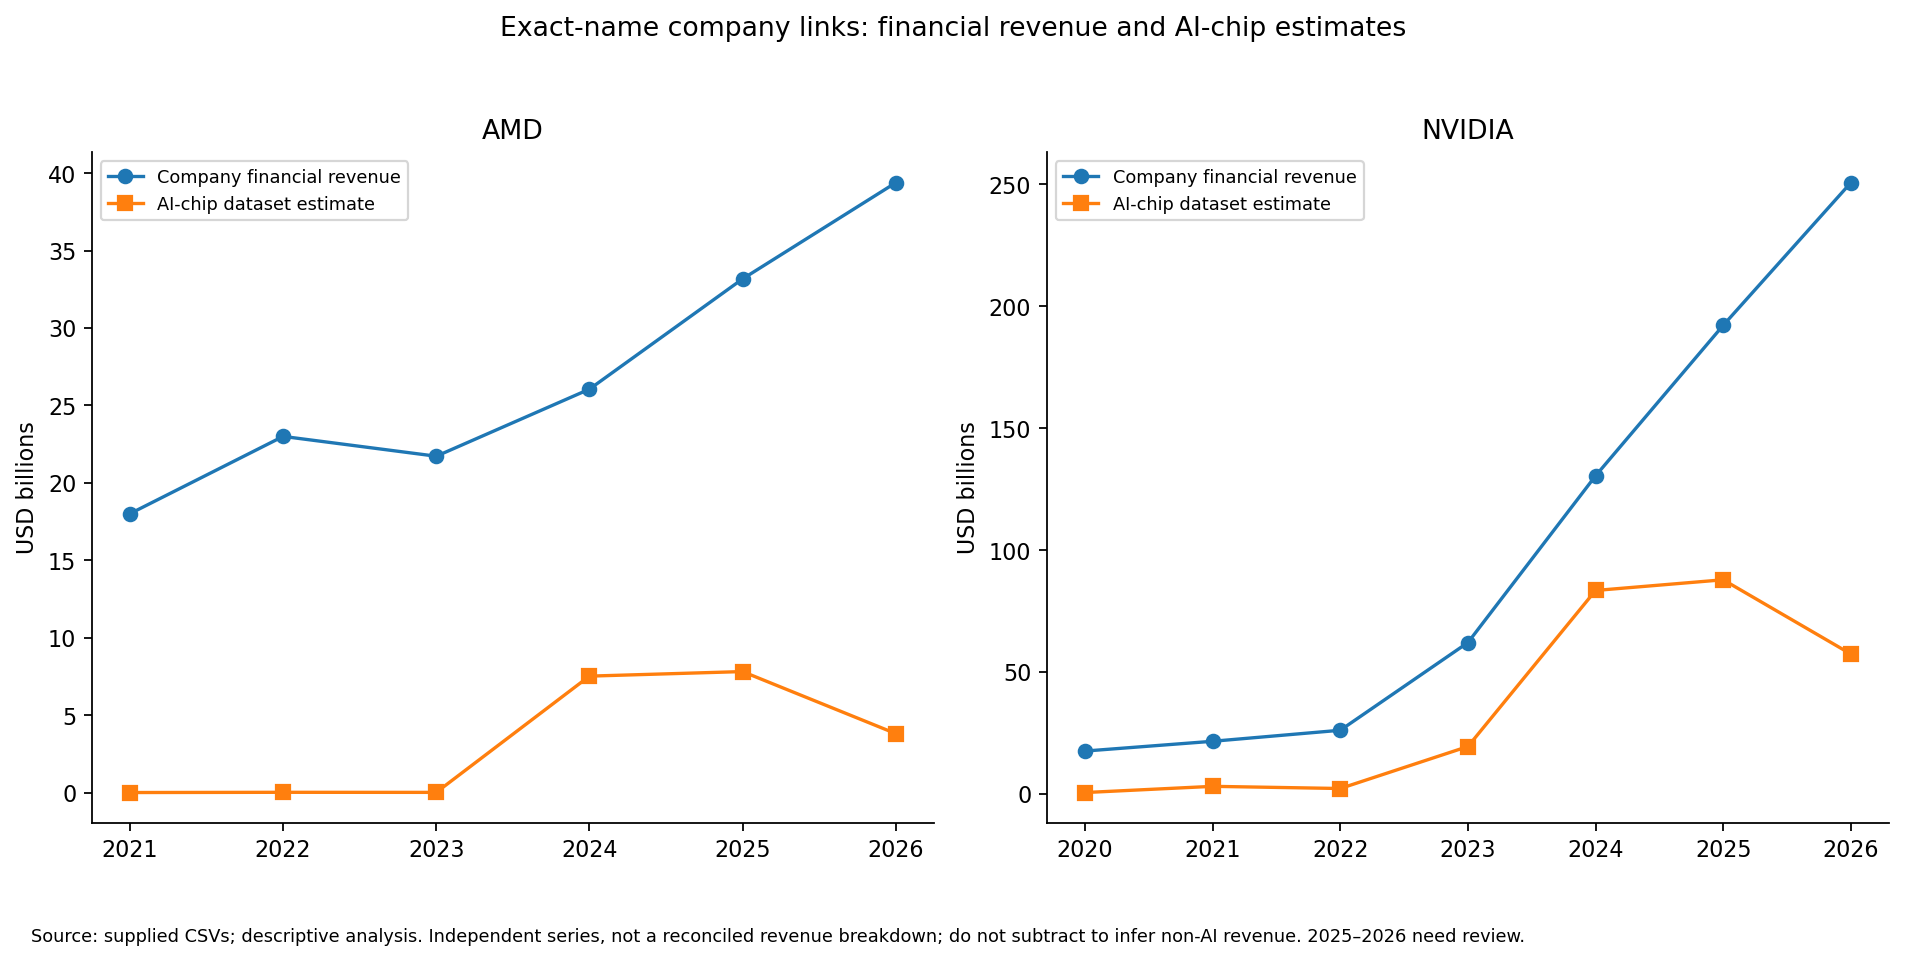

In [9]:
from IPython.display import display, Image
for name in ["period_coverage", "ai_annual", "price_coverage", "review_flags"]:
    print(name)
    display(tables[name])
for path in chart_files:
    display(Image(filename=str(path)))